# Financial Fraud Tabular Detection: Comprehensive EDA & Behavioral Analysis
**Notebook:** `01.EDANotebook.ipynb`  
**Target Environment:** `conquer_m3_frauddetection`  
**Master Project Goal:** Aligned with [Project_Goal.md](../doc/Project_Goal.md)  
**Structured Report:** [eda_result.md](../doc/eda_result.md)  

---

### Core Research Objective:
> *"Mô hình nào tối đa fraud amount captured nhưng vẫn kiểm soát false decline, độ trễ serving và thay đổi hành vi theo thời gian?"*

---

## Phase 1: Environment Setup, Data Ingestion & Memory Profiling
In this phase, we verify package dependencies, load the raw PaySim financial transaction logs (~6.36M rows), benchmark memory consumption before and after dtype downcasting, and execute comprehensive data integrity checks.

In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print(f"Python Version: {sys.version}")
print(f"Pandas Version: {pd.__version__}")
print(f"Numpy Version: {np.__version__}")

Python Version: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
Pandas Version: 3.0.5
Numpy Version: 2.4.6


In [2]:
# 1.1 Ingestion & Memory Profiling
data_path = os.path.join("..", "Dataset", "PS_20174392719_1491204439457_log.csv")
if not os.path.exists(data_path):
    data_path = "Dataset/PS_20174392719_1491204439457_log.csv"

t0 = time.time()
df_raw = pd.read_csv(data_path)
t_load = time.time() - t0

mem_raw_mb = df_raw.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Raw Data Loaded in: {t_load:.2f} seconds")
print(f"Dataset Dimensions: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Raw Memory Usage: {mem_raw_mb:.2f} MB")

Raw Data Loaded in: 8.22 seconds
Dataset Dimensions: 6,362,620 rows x 11 columns
Raw Memory Usage: 1598.19 MB


In [3]:
# 1.2 Memory Optimization via Downcasting
dtypes_opt = {
    'step': 'uint16',
    'type': 'category',
    'amount': 'float64',
    'nameOrig': 'string',
    'oldbalanceOrg': 'float64',
    'newbalanceOrig': 'float64',
    'nameDest': 'string',
    'oldbalanceDest': 'float64',
    'newbalanceDest': 'float64',
    'isFraud': 'int8',
    'isFlaggedFraud': 'int8'
}
df = df_raw.astype(dtypes_opt)
mem_opt_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Optimized Memory Usage: {mem_opt_mb:.2f} MB")
print(f"Memory Reduction: {(1 - mem_opt_mb / mem_raw_mb) * 100:.1f}%")
display(df.head(5))

Optimized Memory Usage: 1092.00 MB
Memory Reduction: 31.7%


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# 1.3 Data Integrity & Quality Audit
print("=== Missing Value Audit ===")
print(df.isna().sum())

print("\n=== Duplicate Rows ===")
print(f"Duplicate count: {df.duplicated().sum()}")

print("\n=== Numerical Range Checks ===")
print(f"Negative Amounts: {(df['amount'] < 0).sum()}")
print(f"Negative Origin Balances: {((df['oldbalanceOrg'] < 0) | (df['newbalanceOrig'] < 0)).sum()}")
print(f"Negative Dest Balances: {((df['oldbalanceDest'] < 0) | (df['newbalanceDest'] < 0)).sum()}")
print(f"Step Range: {df['step'].min()} to {df['step'].max()} (hours)")

=== Missing Value Audit ===


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

=== Duplicate Rows ===


Duplicate count: 0

=== Numerical Range Checks ===
Negative Amounts: 0
Negative Origin Balances: 0
Negative Dest Balances: 0
Step Range: 1 to 743 (hours)


## Phase 2: Target & Class Imbalance Deep Dive (Count vs. Monetary Value)
Financial fraud is characterized by extreme class imbalance by transaction count, but disproportionate monetary impact. We quantify both volume and value dimensions, examine amount distributions, and evaluate the legacy rule `isFlaggedFraud`.

In [5]:
# 2.1 Transaction Count & Monetary Value Imbalance
total_tx = len(df)
n_legit = (df['isFraud'] == 0).sum()
n_fraud = (df['isFraud'] == 1).sum()
fraud_rate = (n_fraud / total_tx) * 100

total_amount = df['amount'].sum()
legit_amount = df[df['isFraud'] == 0]['amount'].sum()
fraud_amount = df[df['isFraud'] == 1]['amount'].sum()
fraud_amount_share = (fraud_amount / total_amount) * 100

imbalance_df = pd.DataFrame({
    'Class': ['Legitimate (0)', 'Fraud (1)', 'Total'],
    'Transaction Count': [f"{n_legit:,}", f"{n_fraud:,}", f"{total_tx:,}"],
    'Count Share (%)': [f"{n_legit/total_tx*100:.4f}%", f"{fraud_rate:.4f}%", "100.0%"],
    'Total Amount ($)': [f"${legit_amount:,.2f}", f"${fraud_amount:,.2f}", f"${total_amount:,.2f}"],
    'Monetary Share (%)': [f"{legit_amount/total_amount*100:.4f}%", f"{fraud_amount_share:.4f}%", "100.0%"]
})
display(imbalance_df)

,Class,Transaction Count,Count Share (%),Total Amount ($),Monetary Share (%)
0,Legitimate (0),"6,354,407",99.8709%,"$1,132,336,529,331.93",98.9465%
1,Fraud (1),"8,213",0.1291%,"$12,056,415,427.84",1.0535%
2,Total,"6,362,620",100.0%,"$1,144,392,944,759.77",100.0%


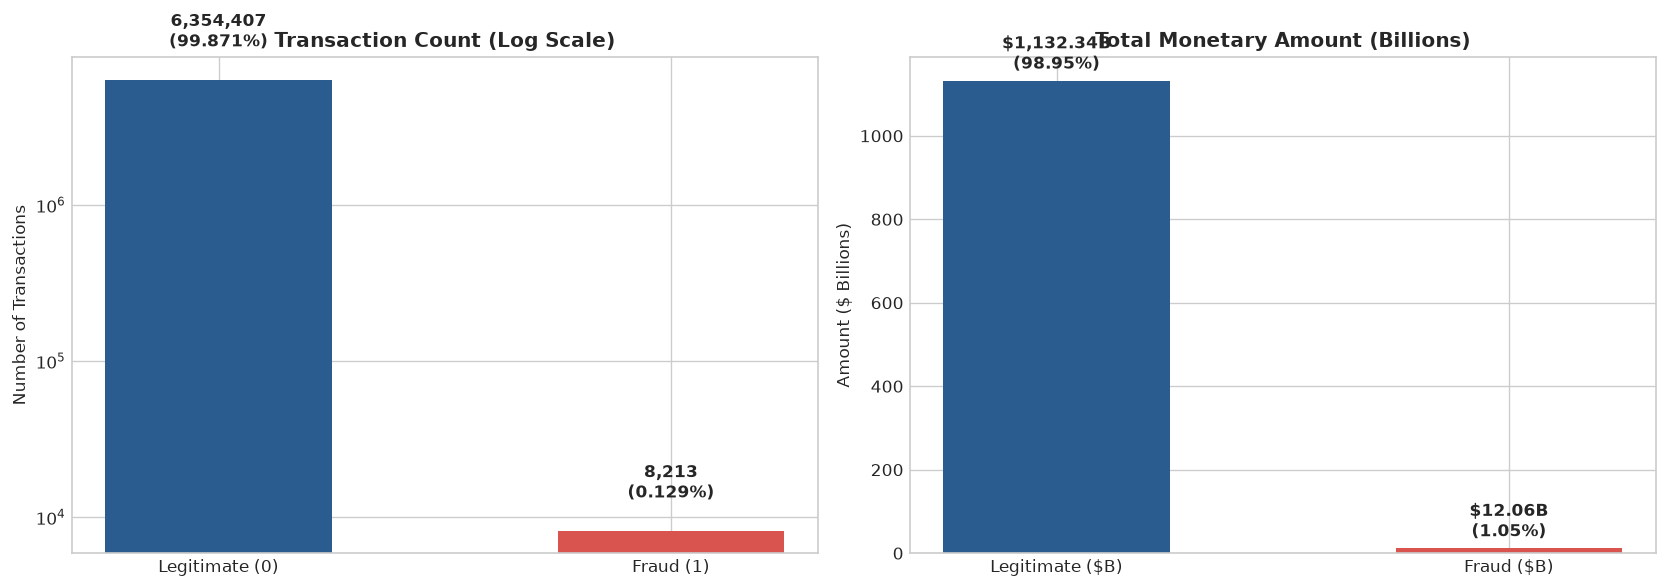

In [6]:
# 2.2 Visualizing Count vs Amount Imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
bars1 = axes[0].bar(['Legitimate (0)', 'Fraud (1)'], [n_legit, n_fraud], color=['#2b5c8f', '#d9534f'], width=0.5)
axes[0].set_yscale('log')
axes[0].set_title('Transaction Count (Log Scale)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval * 1.5, f"{yval:,}\n({yval/total_tx*100:.3f}%)", ha='center', va='bottom', fontweight='bold')

# Amount
bars2 = axes[1].bar(['Legitimate ($B)', 'Fraud ($B)'], [legit_amount/1e9, fraud_amount/1e9], color=['#2b5c8f', '#d9534f'], width=0.5)
axes[1].set_title('Total Monetary Amount (Billions)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amount ($ Billions)')
for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 15, f"${yval:,.2f}B\n({yval/(total_amount/1e9)*100:.2f}%)", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# 2.3 Statistical Quantiles of Transaction Amount
amount_stats = pd.concat([
    df[df['isFraud'] == 0]['amount'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]),
    df[df['isFraud'] == 1]['amount'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
], axis=1)
amount_stats.columns = ['Legitimate Amount ($)', 'Fraud Amount ($)']
amount_stats['Fraud / Legit Ratio'] = amount_stats['Fraud Amount ($)'] / amount_stats['Legitimate Amount ($)']
display(amount_stats.map(lambda x: f"{x:,.2f}"))

,Legitimate Amount ($),Fraud Amount ($),Fraud / Legit Ratio
count,"6,354,407.00","8,213.00",0.00
mean,"178,197.04","1,467,967.30",8.24
std,"596,236.98","2,404,252.95",4.03
min,0.01,0.00,0.00
25%,"13,368.40","127,091.33",9.51
50%,"74,684.72","441,423.44",5.91
75%,"208,364.76","1,517,771.48",7.28
90%,"364,373.44","4,521,723.51",12.41
95%,"515,610.42","8,006,429.04",15.53
99%,"1,586,064.17","10,000,000.00",6.30


In [8]:
# 2.4 Baseline Heuristic Rule Critique (isFlaggedFraud)
flagged_cm = pd.crosstab(df['isFraud'], df['isFlaggedFraud'], rownames=['Actual isFraud'], colnames=['Flagged by Rule'])
display(flagged_cm)

tp_flag = ((df['isFraud'] == 1) & (df['isFlaggedFraud'] == 1)).sum()
fn_flag = ((df['isFraud'] == 1) & (df['isFlaggedFraud'] == 0)).sum()
captured_val = df[(df['isFraud'] == 1) & (df['isFlaggedFraud'] == 1)]['amount'].sum()
missed_val = df[(df['isFraud'] == 1) & (df['isFlaggedFraud'] == 0)]['amount'].sum()

print(f"Baseline Rule Precision: {tp_flag / (tp_flag + 0) * 100:.2f}%")
print(f"Baseline Rule Recall: {tp_flag / (tp_flag + fn_flag) * 100:.4f}% ({tp_flag} / {n_fraud})")
print(f"Monetary Amount Captured: ${captured_val:,.2f} ({captured_val/fraud_amount*100:.2f}%)")
print(f"Monetary Amount Missed: ${missed_val:,.2f} ({missed_val/fraud_amount*100:.2f}%)")

Flagged by Rule,0,1
Actual isFraud,,
0,6354407,0
1,8197,16


Baseline Rule Precision: 100.00%
Baseline Rule Recall: 0.1948% (16 / 8213)
Monetary Amount Captured: $77,785,563.69 (0.65%)
Monetary Amount Missed: $11,978,629,864.15 (99.35%)


## Phase 3: Transaction Type Analysis & Fraud Concentration
We analyze transaction volume across all 5 types (`PAYMENT`, `TRANSFER`, `CASH_OUT`, `DEBIT`, `CASH_IN`) to determine fraud channel distribution and formulate data filtering strategies for XGBoost.

In [9]:
# 3.1 Breakdown by Transaction Type
type_group = df.groupby('type', observed=False).agg(
    total_tx=('isFraud', 'count'),
    fraud_tx=('isFraud', 'sum'),
    total_amount=('amount', 'sum'),
    fraud_amount=('amount', lambda x: x[df.loc[x.index, 'isFraud'] == 1].sum())
).reset_index()

type_group['count_pct'] = (type_group['total_tx'] / total_tx) * 100
type_group['fraud_rate_pct'] = (type_group['fraud_tx'] / type_group['total_tx']) * 100
type_group['fraud_amount_share_pct'] = (type_group['fraud_amount'] / type_group['total_amount']) * 100

display(type_group)

,type,total_tx,fraud_tx,total_amount,fraud_amount,count_pct,fraud_rate_pct,fraud_amount_share_pct
0,CASH_IN,1399284,0,2.363674e+11,0.000000e+00,21.992261,0.000000,0.000000
1,CASH_OUT,2237500,4116,3.944130e+11,5.989202e+09,35.166331,0.183955,1.518510
2,DEBIT,41432,0,2.271992e+08,0.000000e+00,0.651178,0.000000,0.000000
3,PAYMENT,2151495,0,2.809337e+10,0.000000e+00,33.814608,0.000000,0.000000
4,TRANSFER,532909,4097,4.852920e+11,6.067213e+09,8.375622,0.768799,1.250219


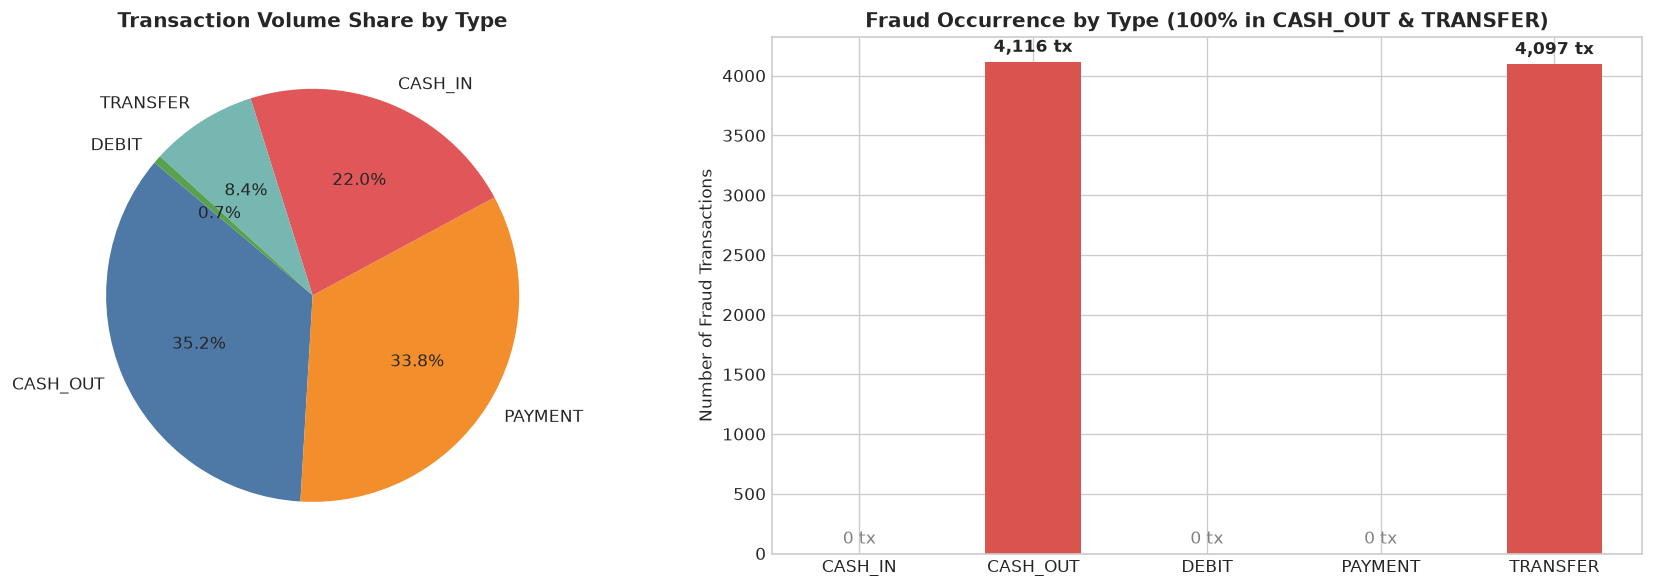

In [10]:
# 3.2 Visualizing Fraud Concentration by Type
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Volume share
type_counts = df['type'].value_counts()
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
axes[0].set_title('Transaction Volume Share by Type', fontsize=12, fontweight='bold')

# Fraud count by type
bar_f = axes[1].bar(type_group['type'], type_group['fraud_tx'], color=['#2b5c8f' if f == 0 else '#d9534f' for f in type_group['fraud_tx']], width=0.55)
axes[1].set_title('Fraud Occurrence by Type (100% in CASH_OUT & TRANSFER)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Fraud Transactions')
for bar in bar_f:
    y = bar.get_height()
    if y > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2.0, y + 50, f"{int(y):,} tx", ha='center', va='bottom', fontweight='bold')
    else:
        axes[1].text(bar.get_x() + bar.get_width()/2.0, 50, "0 tx", ha='center', va='bottom', color='gray')

plt.tight_layout()
plt.show()

## Phase 4: Balance Transition Mechanics & Accounting Errors
We audit the balance arithmetic:
- Origin Error: $\Delta 	ext{Orig} = 	ext{newbalanceOrig} + 	ext{amount} - 	ext{oldbalanceOrg}$
- Destination Error: $\Delta 	ext{Dest} = 	ext{oldbalanceDest} + 	ext{amount} - 	ext{newbalanceDest}$
- Zero-balance states on origin and destination accounts.

In [11]:
# 4.1 Balance Error Computation
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

err_stats = pd.concat([
    df[df['isFraud'] == 0][['errorBalanceOrig', 'errorBalanceDest']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    df[df['isFraud'] == 1][['errorBalanceOrig', 'errorBalanceDest']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
], axis=1, keys=['Legitimate (0)', 'Fraud (1)'])

display(err_stats.map(lambda x: f"{x:,.2f}"))

Legitimate (0)                         Fraud (1)                 
      errorBalanceOrig errorBalanceDest errorBalanceOrig errorBalanceDest
count     6,354,407.00     6,354,407.00         8,213.00         8,213.00
mean        201,338.56        54,692.23        10,692.33       732,509.30
std         606,928.89       436,002.63       265,146.13     1,867,747.99
min              -0.01   -75,885,725.63            -0.00    -8,875,516.29
1%               -0.00      -353,775.55             0.00       -33,915.89
5%                0.00            -0.01             0.00            -0.00
50%          69,049.31         3,500.68             0.00         2,231.46
95%         701,154.97       455,576.53             0.00     4,555,771.26
99%       1,560,577.33       788,640.33             0.00    10,000,000.00
max      92,445,516.64    13,191,233.98    10,000,000.00    10,000,000.00

In [12]:
# 4.2 Zero-Balance Anomalies & Drain Profile
orig_drain_legit = ((df['isFraud'] == 0) & (df['newbalanceOrig'] == 0)).sum() / (df['isFraud'] == 0).sum() * 100
orig_drain_fraud = ((df['isFraud'] == 1) & (df['newbalanceOrig'] == 0)).sum() / (df['isFraud'] == 1).sum() * 100

dest_both_zero_legit = ((df['isFraud'] == 0) & (df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0)).sum() / (df['isFraud'] == 0).sum() * 100
dest_both_zero_fraud = ((df['isFraud'] == 1) & (df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0)).sum() / (df['isFraud'] == 1).sum() * 100

zero_comp = pd.DataFrame({
    'Anomaly Signature': [
        'Origin Account Fully Drained (newbalanceOrig == 0)',
        'Dest Zero Before & After (oldbalanceDest == 0 & newbalanceDest == 0)'
    ],
    'Legitimate Rate (%)': [f"{orig_drain_legit:.2f}%", f"{dest_both_zero_legit:.2f}%"],
    'Fraud Rate (%)': [f"{orig_drain_fraud:.2f}%", f"{dest_both_zero_fraud:.2f}%"]
})
display(zero_comp)

,Anomaly Signature,Legitimate Rate (%),Fraud Rate (%)
0,Origin Account Fully Drained (newbalanceOrig =...,56.68%,98.05%
1,Dest Zero Before & After (oldbalanceDest == 0 ...,36.40%,49.63%


## Phase 5: Temporal Dynamics & Time-Based Split Strategy
We extract diurnal features (`hour = step % 24`, `day = step // 24`), analyze 24-hour activity curves, longitudinal drift over 744 steps, and formulate the Time-Based Split Protocol.

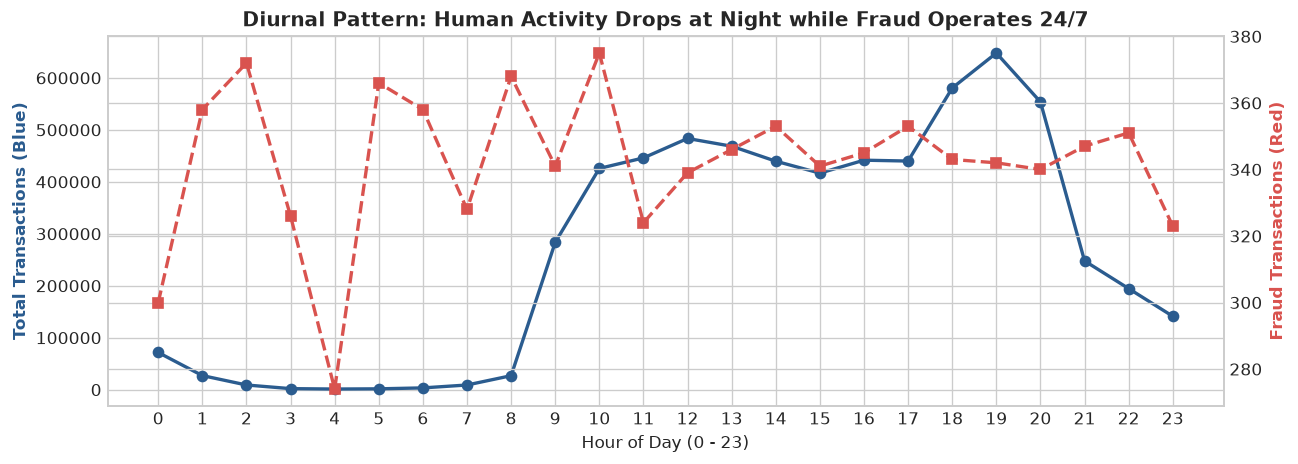

In [13]:
# 5.1 Temporal Feature Extraction & Hourly Patterns
df['hour'] = (df['step'] % 24).astype('uint8')
df['day'] = (df['step'] // 24).astype('uint16')

hourly = df.groupby('hour').agg(
    total_tx=('isFraud', 'count'),
    fraud_tx=('isFraud', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.plot(hourly['hour'], hourly['total_tx'], color='#2b5c8f', marker='o', linewidth=2, label='Total Volume')
ax2.plot(hourly['hour'], hourly['fraud_tx'], color='#d9534f', marker='s', linewidth=2, linestyle='--', label='Fraud Volume')

ax1.set_title('Diurnal Pattern: Human Activity Drops at Night while Fraud Operates 24/7', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hour of Day (0 - 23)')
ax1.set_ylabel('Total Transactions (Blue)', color='#2b5c8f', fontweight='bold')
ax2.set_ylabel('Fraud Transactions (Red)', color='#d9534f', fontweight='bold')
ax1.set_xticks(range(0, 24))
plt.show()

In [14]:
# 5.2 Formal Time-Based Split Protocol Formulation
train_mask = df['step'] <= 480
val_mask = (df['step'] > 480) & (df['step'] <= 600)
test_mask = df['step'] > 600

splits_table = pd.DataFrame([
    {
        'Split Partition': 'Train Set (Days 1 - 20)',
        'Step Range': '1 <= step <= 480',
        'Total Rows': f"{train_mask.sum():,}",
        'Share (%)': f"{train_mask.sum()/total_tx*100:.2f}%",
        'Fraud Count': f"{df[train_mask]['isFraud'].sum():,}",
        'Fraud Rate (%)': f"{df[train_mask]['isFraud'].mean()*100:.4f}%",
        'Total Amount ($B)': f"${df[train_mask]['amount'].sum()/1e9:,.2f}B",
        'Fraud Amount ($B)': f"${df[train_mask & (df['isFraud']==1)]['amount'].sum()/1e9:,.2f}B"
    },
    {
        'Split Partition': 'Validation Set (Days 21 - 25)',
        'Step Range': '481 <= step <= 600',
        'Total Rows': f"{val_mask.sum():,}",
        'Share (%)': f"{val_mask.sum()/total_tx*100:.2f}%",
        'Fraud Count': f"{df[val_mask]['isFraud'].sum():,}",
        'Fraud Rate (%)': f"{df[val_mask]['isFraud'].mean()*100:.4f}%",
        'Total Amount ($B)': f"${df[val_mask]['amount'].sum()/1e9:,.2f}B",
        'Fraud Amount ($B)': f"${df[val_mask & (df['isFraud']==1)]['amount'].sum()/1e9:,.2f}B"
    },
    {
        'Split Partition': 'Out-of-Time Test Set (Days 26 - 30)',
        'Step Range': '601 <= step <= 744',
        'Total Rows': f"{test_mask.sum():,}",
        'Share (%)': f"{test_mask.sum()/total_tx*100:.2f}%",
        'Fraud Count': f"{df[test_mask]['isFraud'].sum():,}",
        'Fraud Rate (%)': f"{df[test_mask]['isFraud'].mean()*100:.4f}%",
        'Total Amount ($B)': f"${df[test_mask]['amount'].sum()/1e9:,.2f}B",
        'Fraud Amount ($B)': f"${df[test_mask & (df['isFraud']==1)]['amount'].sum()/1e9:,.2f}B"
    }
])
display(splits_table)

,Split Partition,Step Range,Total Rows,Share (%),Fraud Count,Fraud Rate (%),Total Amount ($B),Fraud Amount ($B)
0,Train Set (Days 1 - 20),1 <= step <= 480,"6,039,443",94.92%,"5,349",0.0886%,"$1,088.63B",$7.74B
1,Validation Set (Days 21 - 25),481 <= step <= 600,"219,604",3.45%,"1,264",0.5756%,$36.97B,$1.66B
2,Out-of-Time Test Set (Days 26 - 30),601 <= step <= 744,"103,573",1.63%,"1,600",1.5448%,$18.79B,$2.66B


## Phase 6: Entity Behavior & Network Characteristics
We investigate account identifiers (`nameOrig`, `nameDest`), customer vs merchant interaction patterns, and mule laundering chains.

In [15]:
# 6.1 Account Cardinality & Merchant Analysis
print(f"Unique Origin Accounts (nameOrig): {df['nameOrig'].nunique():,}")
print(f"Unique Destination Accounts (nameDest): {df['nameDest'].nunique():,}")

merchant_dests = df['nameDest'].str.startswith('M')
print(f"Transactions targeting Merchants (M): {merchant_dests.sum():,}")
print(f"Fraud transactions targeting Merchants (M): {(merchant_dests & (df['isFraud'] == 1)).sum()}")

transfer_dests = set(df[df['type'] == 'TRANSFER']['nameDest'].unique())
cashout_origs = set(df[df['type'] == 'CASH_OUT']['nameOrig'].unique())
mules = transfer_dests.intersection(cashout_origs)
print(f"Detected Mule Accounts (TRANSFER Dest -> CASH_OUT Orig): {len(mules):,}")

Unique Origin Accounts (nameOrig): 6,353,307


Unique Destination Accounts (nameDest): 2,722,362


Transactions targeting Merchants (M): 2,151,495
Fraud transactions targeting Merchants (M): 0


Detected Mule Accounts (TRANSFER Dest -> CASH_OUT Orig): 249


## Phase 7 & 8: Feature Correlations & XGBoost Engineering Backlog
We compute target correlations on the filtered `TRANSFER` + `CASH_OUT` subset and summarize prioritized features for the XGBoost model pipeline.

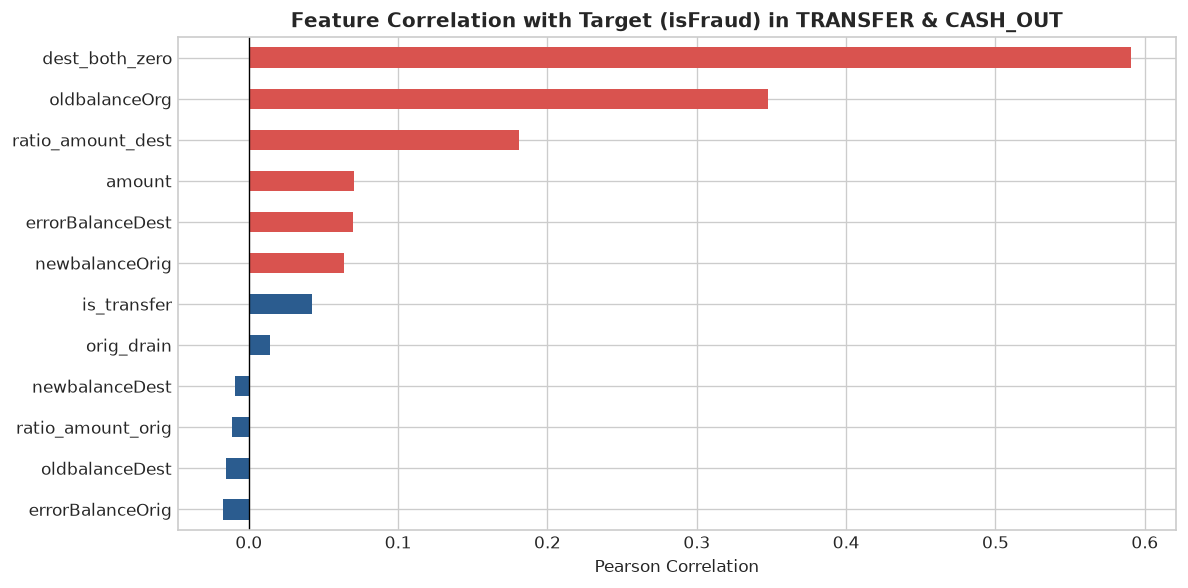

In [16]:
# 7.1 Feature Correlations in TRANSFER & CASH_OUT Subset
subset_tc = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
subset_tc['is_transfer'] = (subset_tc['type'] == 'TRANSFER').astype(int)
subset_tc['orig_drain'] = (subset_tc['newbalanceOrig'] == 0).astype(int)
subset_tc['dest_both_zero'] = ((subset_tc['oldbalanceDest'] == 0) & (subset_tc['newbalanceDest'] == 0)).astype(int)
subset_tc['ratio_amount_orig'] = subset_tc['amount'] / (subset_tc['oldbalanceOrg'] + 1.0)
subset_tc['ratio_amount_dest'] = subset_tc['amount'] / (subset_tc['oldbalanceDest'] + 1.0)

corr_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest',
                 'errorBalanceOrig', 'errorBalanceDest', 'is_transfer', 'orig_drain', 'dest_both_zero',
                 'ratio_amount_orig', 'ratio_amount_dest']

corrs = subset_tc[corr_features].apply(lambda x: x.corr(subset_tc['isFraud'])).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
corrs.plot(kind='barh', color=['#d9534f' if v > 0.05 else '#2b5c8f' for v in corrs])
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.title('Feature Correlation with Target (isFraud) in TRANSFER & CASH_OUT', fontsize=12, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## Summary & Next Steps for XGBoost Pipeline
1. **Subsetting:** Train on `TRANSFER` + `CASH_OUT` ($N = 2,770,409$).
2. **Features to Implement:** `errorBalanceOrig`, `errorBalanceDest`, `dest_both_zero`, `orig_drain_flag`, `ratio_amount_orig`, `ratio_amount_dest`, `hour_of_day`, `is_transfer`, `amount_log10`.
3. **Time Split:** Train on Steps 1–480, Validate on Steps 481–600, Test on Steps 601–744.
4. **Imbalance Strategy:** `scale_pos_weight = 336.32` and value-weighted objective optimization.